In [1]:
import importlib
import PerceptronSimple
importlib.reload(PerceptronSimple)


<module 'PerceptronSimple' from '/home/fausto/Documentos/facultad/Inteligencia Computacional/Practica/Guia1/PerceptronSimple.py'>

In [2]:
import matplotlib.pyplot as plt
import numpy as np

Época   1 | Errores:   1
Época   2 | Errores:   0
Pesos:  [-0.2745767   0.32595662  0.33199057]
Precision en test:  1.0


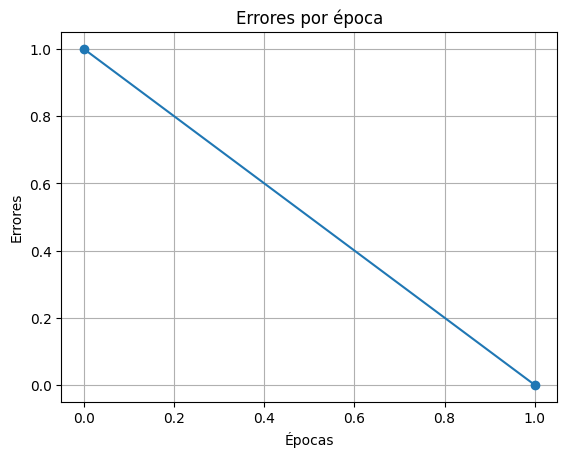

In [3]:
from PerceptronSimple import PerceptronSimple

X_50_train, y_50_train = PerceptronSimple.cargar_csv("./data/OR_50_trn.csv")
X_50_test, y_50_test = PerceptronSimple.cargar_csv("./data/OR_50_tst.csv")

p = PerceptronSimple(tasa_aprendizaje=0.01, max_epocas=10, tolerancia=0)
p.entrenar(X_50_train, y_50_train)

print("Pesos: ", p.w)
print("Precision en test: ", p.evaluar(X_50_test, y_50_test))

plt.plot(p.errores, marker="o")
plt.title("Errores por época")
plt.xlabel("Épocas")
plt.ylabel("Errores")
plt.grid(True)
plt.show()

In [ ]:
def plot(inputs, output, weight_list, title):
    x1 = inputs[:, 0]
    x2 = inputs[:, 1]

    pos = output == 1
    neg = output == -1
    plt.figure(figsize=(7,5))
    plt.scatter(x1[pos], x2[pos], marker='o', label='Clase +1', alpha=0.9)
    plt.scatter(x1[neg], x2[neg], marker='x', label='Clase -1', alpha=0.9)
    
    xs = np.linspace(-5, 5, 200)  

    # Graficar TODAS las rectas guardadas
    for k, w in enumerate(weight_list, start=1):
        w0, w1, w2 = w
        if abs(w2) < 1e-12:  # caso recta casi vertical
            if abs(w1) > 1e-12:
                plt.axvline(w0 / w1, alpha=0.25, linewidth=1)
            continue
        ys = (w0 / w2) - (w1 / w2) * xs
        alpha = 0.15 + 0.85 * (k / len(weight_list))  # transparencia gradual
        lw = 1 if k < len(weight_list) else 2.5       # última más gruesa
        plt.plot(xs, ys, alpha=alpha, linewidth=lw, label=f"Paso {k}")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.xlim(-3, 3)   # límite eje x
    plt.ylim(-3, 3)   # límite eje y
    plt.tight_layout()
    plt.show()

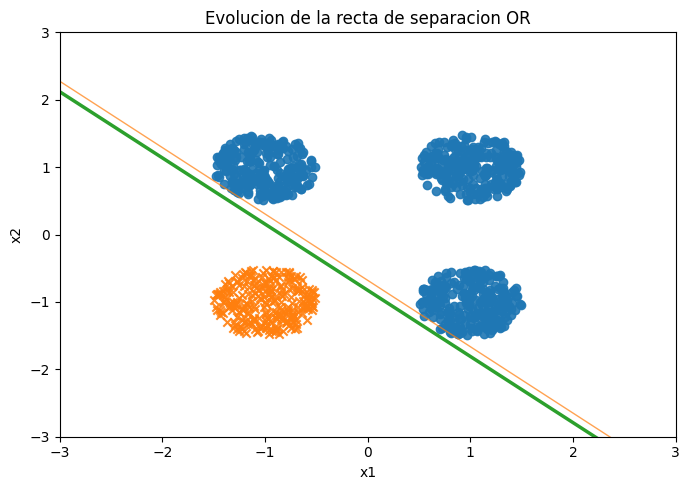

In [5]:
plot(X_50_train, y_50_train, p.hist_w, "Evolucion de la recta de separacion OR")

Se puede observar que por mas que los puntos tienen una dispersión mayor, el problema sigue siendo linealmente separable.

Época   1 | Errores:  70
Época   2 | Errores:  72
Época   3 | Errores:  62
Época   4 | Errores:  47
Época   5 | Errores:  46
Época   6 | Errores:  45
Época   7 | Errores:  50
Época   8 | Errores:  69
Época   9 | Errores:  70
Época  10 | Errores:  71
Pesos:  [-1.95093327  1.49609     1.28226451]
Precision en test:  0.93


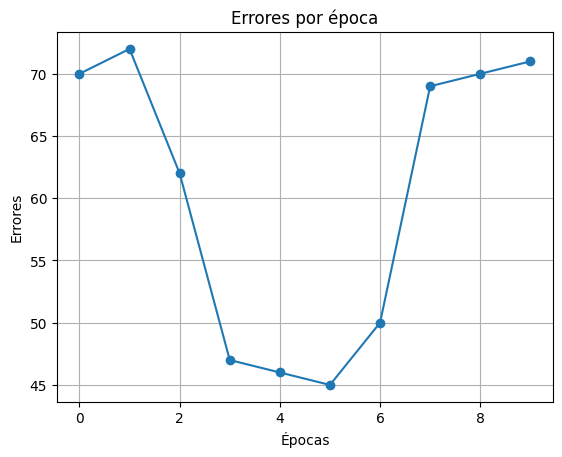

In [6]:
X_90_train, y_90_train = PerceptronSimple.cargar_csv("./data/OR_90_trn.csv")
X_90_test, y_90_test = PerceptronSimple.cargar_csv("./data/OR_90_tst.csv")

p1 = PerceptronSimple(tasa_aprendizaje=0.1, max_epocas=10, tolerancia=0)
p1.entrenar(X_90_train, y_90_train)

print("Pesos: ", p1.w)
print("Precision en test: ", p.evaluar(X_90_test, y_90_test))

plt.plot(p1.errores, marker="o")
plt.title("Errores por época")
plt.xlabel("Épocas")
plt.ylabel("Errores")
plt.grid(True)
plt.show()

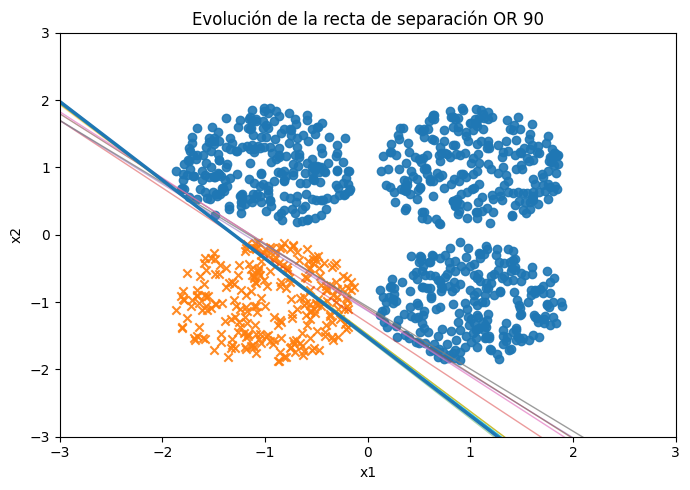

In [8]:

plot(X_90_train, y_90_train, p1.hist_w, "Evolución de la recta de separación OR 90")


Para este caso donde el ruido es muy alto 90%, podemos observar que es imposible separar los dos grupos solamente utilizando una recta